# 휴먼 vs 매크로 행동 데이터 EDA

**범위:** EDA 1-3단계 (4. Personal EDA, 5. 분석 리포트는 본인 작업).

**파이프라인:** `mouse_automation_lv2` (lv2_collector + human_recorder).
기존 `browser_automation` 데이터셋과 격리 — Q4 결정.

In [44]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [45]:
fonts = sorted(set(f.name for f in fm.fontManager.ttflist))

for font in fonts:
    if any(keyword in font.lower() for keyword in ["nanum", "noto", "malgun", "apple", "gothic"]):
        print(font)

Century Gothic
Copperplate Gothic Bold
Copperplate Gothic Light
Franklin Gothic Book
Franklin Gothic Demi
Franklin Gothic Demi Cond
Franklin Gothic Heavy
Franklin Gothic Medium
Franklin Gothic Medium Cond
HYGothic-Extra
HYGothic-Medium
MS Gothic
Malgun Gothic
Noto Sans KR
Noto Serif KR
Showcard Gothic
Yu Gothic


In [46]:
# 노트북 세팅
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

# 한글 폰트 적용
for _font in ["Malgun Gothic", "Nanum Gothic", "AppleGothic"]:
    try:
        plt.rcParams["font.family"] = _font
        print(f"한글 폰트 적용: {_font}")
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False

한글 폰트 적용: Malgun Gothic


## 1. 데이터 준비

In [47]:
# 데이터 경로 설정
ROOT = Path.cwd()

if(ROOT.name != "EDA"):
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

DATA_DIR = Path("../../data/behavior")

# DEVIATION (chan): pipeline_filter 추가 — Q4 결정 (browser_automation 격리)
PIPELINE_FILTER = "mouse_automation_lv2"

print(ROOT)
print(DATA_DIR)
print("PIPELINE_FILTER:", PIPELINE_FILTER)

c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\EDA
..\..\data\behavior
PIPELINE_FILTER: mouse_automation_lv2


In [48]:
feature_config_path = Path("../../configs/feature_config.yaml")

with open(feature_config_path, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config["names_ko"]
EXCLUDE_COL = feature_config["exclude"]  # trial_id, label, stage, selectedSeats 제외

CLICK_FEATURES = FEATURE_GROUPS["click"]
MOUSE_FEATURES = FEATURE_GROUPS["mouse"]
KEYBOARD_FEATURES = FEATURE_GROUPS["keyboard"]

BEHAVIOR_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]

print("행동 feature 개수:", len(BEHAVIOR_FEATURES))

행동 feature 개수: 44


In [49]:
# 행동 데이터 로드

def load_data(data_dir: Path, pipeline_filter: str | None = None) -> pd.DataFrame:
    """trial_*.json -> DataFrame.

    Args:
        data_dir (Path): 데이터 디렉토리
        pipeline_filter (str | None): summary.collection_pipeline 일치 trial 만 로드
    Returns:
        pd.DataFrame: 행동 데이터프레임
    """

    rows: list[dict] = []
    skipped_pipeline = 0

    for path in sorted(data_dir.glob("trial_*.json")):

        data = json.loads(path.read_text(encoding="utf-8"))
        label = data.get("label", None)

        if(label is None):
            continue

        # DEVIATION (chan): pipeline_filter 인자 추가 — Q4 결정 (browser_automation 격리)
        summary = data.get("summary", {})
        if pipeline_filter and isinstance(summary, dict):
            if summary.get("collection_pipeline") != pipeline_filter:
                skipped_pipeline += 1
                continue

        id = int(data.get("trialId"))
        feature = data.get("metrics", {})

        row = {
            "trial_id": id,
            "label": label,
        }

        if isinstance(summary, dict):
            # metrics_compatibility 는 dict 라 컬럼화 부적합 → 제외
            row.update({k: v for k, v in summary.items() if k != "metrics_compatibility"})
        if isinstance(feature, dict):
            row.update(feature)
        
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    if skipped_pipeline:
        print(f"skipped (pipeline mismatch): {skipped_pipeline}")
    return df

df = load_data(DATA_DIR, pipeline_filter=PIPELINE_FILTER)

print("데이터 개수:", len(df))
display(df.head())

데이터 개수: 152


,trial_id,label,collection_pipeline,session_id,source,durationMs,clickCount,eventCount,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,pre_click_path_300ms_total_distance_px,pre_click_path_300ms_straightness,pre_click_path_500ms_total_distance_px,pre_click_path_500ms_straightness,time_to_first_keydown_ms,inter_key_interval_ms_mean,inter_key_interval_ms_std,keydown_to_keyup_ms_mean,typing_total_duration_ms,typing_speed_cps,backspace_rate,correction_count,paste_flag,focus_to_submit_ms
0,900001,macro,mouse_automation_lv2,00bcb73bc0e1,pyautogui_lv2_collector,17236.399,15,315,720.770,None,None,1180.551,None,None,None,None,None,None,None,20.0,None,None,None,4038.278,0.234288,1.2167,0.101194,0.002180,0.000065,0.046909,0.095828,33,0,478.474,14,17.405,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,900002,macro,mouse_automation_lv2,021041378170,pyautogui_lv2_collector,16286.176,14,294,700.323,None,None,1199.786,None,None,None,None,None,None,None,20.0,None,None,None,3555.430,0.218310,1.0723,0.106978,0.002339,0.000063,0.043994,0.116348,38,0,454.849,14,17.192,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,900003,macro,mouse_automation_lv2,059f17fc3367,pyautogui_lv2_collector,7824.638,7,147,708.465,None,None,1188.076,None,None,None,None,None,None,None,20.0,None,None,None,1550.996,0.198220,0.9010,0.093095,0.002249,0.000073,0.081172,0.109509,15,0,501.290,6,17.892,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,900004,macro,mouse_automation_lv2,0c6f75e42ef6,pyautogui_lv2_collector,5951.086,5,105,729.841,None,None,1308.470,None,None,None,None,None,None,None,20.0,None,None,None,1321.718,0.222097,0.9441,0.101649,0.002229,0.000069,0.097975,0.094544,8,0,447.499,5,16.804,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,900005,macro,mouse_automation_lv2,0cc1696c51ec,pyautogui_lv2_collector,7530.660,7,147,698.983,None,None,1140.629,None,None,None,None,None,None,None,20.0,None,None,None,1703.110,0.226157,0.9918,0.093017,0.002175,0.000068,0.107481,0.125067,16,0,427.588,7,18.591,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


## 2. 데이터 전처리

In [50]:
# chan 의 add_pre_click_path_features 는 mouse_automation 에선 호출 X.
# 이유: pre_click_mouse_path_pattern_{300|500}ms 가 metrics 에 키로는 있으나
# 값이 100% null. chan 함수의 split 로직이 parts[1] 접근 시 IndexError 위험.
# (호출 안 해도 EDA 1-3 진행 무관.)

print("add_pre_click_path_features: skipped (mouse_automation_lv2 데이터)")

add_pre_click_path_features: skipped (mouse_automation_lv2 데이터)


In [51]:
# DEVIATION (chan): USABLE_FEATURES 신규 — mouse_automation 의 100% null feature 자동 제외
# (DOM/keyboard 28개가 모두 null 이라 학습 입력에서 제외해야 함)

null_rates = df[BEHAVIOR_FEATURES].isna().mean().sort_values(ascending=False)
all_null = null_rates[null_rates == 1.0].index.tolist()

print(f"100% null feature: {len(all_null)} / {len(BEHAVIOR_FEATURES)}")
print("\n100% null (학습 입력 X):")
for f in all_null:
    print(f"  - {f} ({FEATURE_NAME_KR.get(f, f)})")

100% null feature: 28 / 44

100% null (학습 입력 X):
  - time_from_element_visible_to_click_ms (노출 후 클릭)
  - time_from_element_clickable_to_click_ms (활성 후 클릭)
  - click_position_repeat_rate (좌표 반복률)
  - click_sequence_consistency_score (순서 일관성)
  - double_click_rate (더블클릭 비율)
  - misclick_rate (오클릭 비율)
  - click_offset_from_element_center_px (중심 오차)
  - click_offset_variance_px (오차 분산)
  - reclick_rate (재클릭 비율)
  - immediate_post_render_click_rate (즉시 클릭 비율)
  - pre_click_scroll_flag (클릭 전 스크롤)
  - pre_click_hover_time_ms (클릭 전 hover)
  - paste_flag (붙여넣기 여부)
  - correction_count (수정 횟수)
  - focus_to_submit_ms (포커스 후 확인)
  - backspace_rate (백스페이스 비율)
  - typing_speed_cps (초당 입력 수)
  - typing_total_duration_ms (총 입력 시간)
  - keydown_to_keyup_ms_mean (키 누름 시간)
  - inter_key_interval_ms_std (키 간격 표준편차)
  - inter_key_interval_ms_mean (키 간격 평균)
  - time_to_first_keydown_ms (첫 키 입력 시간)
  - pre_click_path_500ms_straightness (500ms 경로 직선성)
  - pre_click_path_500ms_total_distance_px (500ms 경로 총거리)
 

In [52]:
USABLE_FEATURES = [f for f in BEHAVIOR_FEATURES if df[f].notna().any()]

print(f"USABLE feature: {len(USABLE_FEATURES)} / {len(BEHAVIOR_FEATURES)}")

# 그룹별 분포
for group_name, features in FEATURE_GROUPS.items():
    usable_in_group = [f for f in features if f in USABLE_FEATURES]
    print(f"  {group_name}: {len(usable_in_group)} / {len(features)}")

USABLE_FEATURES

USABLE feature: 16 / 44
  click: 3 / 15
  mouse: 13 / 19
  keyboard: 0 / 10


['time_to_first_click_ms',
 'inter_click_interval_ms',
 'pre_click_mousemove_count',
 'mouse_total_travel_distance_px',
 'mouse_avg_speed_px_per_ms',
 'mouse_max_speed_px_per_ms',
 'mouse_speed_change_mean',
 'mouse_acceleration_mean',
 'mouse_jerk_mean',
 'mouse_path_straightness_score',
 'mouse_path_curvature_mean',
 'mouse_direction_change_count',
 'mouse_overshoot_flag',
 'mouse_hover_dwell_time_ms',
 'mouse_stop_segment_count',
 'mousemove_event_rate']

In [53]:
# 정합성 검증 — label↔source, durationMs/clickCount/eventCount 정상 범위

print("=== label x source ===")
print(df.groupby(["label", "source"]).size().to_string())

print("\n=== durationMs (sec) ===")
print((df["durationMs"] / 1000).groupby(df["label"]).describe())

print("\n=== clickCount ===")
print(df["clickCount"].groupby(df["label"]).describe())

print("\n=== eventCount ===")
print(df["eventCount"].groupby(df["label"]).describe())

=== label x source ===
label  source                 
human  human                       51
macro  pyautogui_lv2_collector    101

=== durationMs (sec) ===
       count       mean       std        min        25%        50%        75%        max
label                                                                                   
human   51.0  15.011476  1.893475  12.590610  13.681114  14.675738  15.576338  21.688918
macro  101.0  11.637220  3.785793   4.866047   8.553557  11.364579  14.431356  18.649839

=== clickCount ===
       count       mean       std  min  25%   50%   75%   max
label                                                        
human   51.0   7.117647  0.972565  6.0  6.0   7.0   8.0  10.0
macro  101.0  10.168317  3.079186  5.0  8.0  10.0  13.0  15.0

=== eventCount ===
       count        mean        std    min    25%    50%    75%    max
label                                                                 
human   51.0  259.921569  49.165371  172.0  221.5  254.0  

## 3. 기본 분석

### 3-1 데이터 분포 시각화 (박스 플롯)

In [54]:
# 행동 데이터 통계 요약

def feature_summary(df: pd.DataFrame) -> pd.DataFrame:
    """행동 데이터 통계 정보 요약 & 휴먼, 매크로 비교
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임

    Returns:
        pd.DataFrame: 행동 feature 통계 요약 데이터프레임
    """

    n_rows = max(1, int(df.shape[0]))

    rows: list[dict] = []

    for feature in df.columns:
        if feature in EXCLUDE_COL:
            continue
        s = df[feature].dropna()

        rows.append(
            {
                "feature_ko": FEATURE_NAME_KR.get(feature),
                "count": int(s.shape[0]),
                "mean": float(s.mean()) if s.shape[0] else np.nan,
                "min": float(s.min()) if s.shape[0] else np.nan,
                "max": float(s.max()) if s.shape[0] else np.nan,
            }
        )

    return pd.DataFrame(rows)

human_df = df[df["label"] == "human"]
macro_df = df[df["label"] == "macro"]

human_summary = feature_summary(human_df)
macro_summary = feature_summary(macro_df)

compare_summary = human_summary.merge(
    macro_summary,
    on=["feature_ko"],
    suffixes=("_human", "_macro")
)

compare_summary["mean_diff"] = (
    abs(compare_summary["mean_macro"] - compare_summary["mean_human"])
)

compare_summary = compare_summary[
    [
        "feature_ko",
        "mean_diff",
        "mean_human",
        "mean_macro",
        "min_human",
        "min_macro",
        "max_human",
        "max_macro",
        "count_human",
        "count_macro",
    ]
]

print("휴먼 데이터 수 : ", human_df.shape[0])
print("매크로 데이터 수 : ", macro_df.shape[0])

print("\n행동 feature 통계 요약 비교:")
display(compare_summary)

휴먼 데이터 수 :  51
매크로 데이터 수 :  101

행동 feature 통계 요약 비교:


,feature_ko,mean_diff,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro
0,페이지 체류 시간,3374.255597,15011.475686,11637.220089,12590.610000,4866.047000,21688.918000,18649.839000,51,101
1,클릭 수,3.050670,7.117647,10.168317,6.000000,5.000000,10.000000,15.000000,51,101
2,전체 이벤트 수,46.386915,259.921569,213.534653,172.000000,105.000000,396.000000,315.000000,51,101
3,첫 클릭 시간,704.684656,3.654294,708.338950,0.184000,561.760000,97.636000,848.324000,51,101
4,노출 후 클릭,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5,활성 후 클릭,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,클릭 간격,1122.241097,2312.824176,1190.583079,1535.014000,1050.040000,3448.646000,1362.836000,51,101
7,순서 일관성,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
8,좌표 반복률,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
9,중심 오차,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [55]:
# DEVIATION (chan): Cohen's d — 트리비얼 위험 feature 정량 검증
# |d| >= 0.8 = 큰 효과 (분리력 강함). 단독 분리 99%+ 의심 feature 식별 보조.

def cohen_d(a: pd.Series, b: pd.Series) -> float:
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    if a.shape[0] < 5 or b.shape[0] < 5:
        return float("nan")
    var_a = float(a.var(ddof=1)) if a.shape[0] >= 2 else 0.0
    var_b = float(b.var(ddof=1)) if b.shape[0] >= 2 else 0.0
    pooled = ((a.shape[0] - 1) * var_a + (b.shape[0] - 1) * var_b) / max(a.shape[0] + b.shape[0] - 2, 1)
    if pooled <= 0:
        return float("nan")
    return float((b.mean() - a.mean()) / np.sqrt(pooled))

effects: list[dict] = []
for f in USABLE_FEATURES:
    d = cohen_d(df[df["label"] == "human"][f], df[df["label"] == "macro"][f])
    effects.append({
        "feature_ko": FEATURE_NAME_KR.get(f, f),
        "feature": f,
        "cohen_d": d,
        "abs_d": abs(d) if not pd.isna(d) else 0.0,
    })

effects_df = pd.DataFrame(effects).sort_values("abs_d", ascending=False).reset_index(drop=True)
print("Cohen's d 기준 분리력 (|d| >= 0.8 = 큰 효과):")
display(effects_df)

Cohen's d 기준 분리력 (|d| >= 0.8 = 큰 효과):


,feature_ko,feature,cohen_d,abs_d
0,첫 클릭 시간,time_to_first_click_ms,14.045595,14.045595
1,클릭 간격,inter_click_interval_ms,-4.754130,4.754130
2,속도 변화,mouse_speed_change_mean,-4.468336,4.468336
3,총 이동 거리,mouse_total_travel_distance_px,-3.389264,3.389264
4,평균 속도,mouse_avg_speed_px_per_ms,-3.030646,3.030646
5,클릭 전 이동 수,pre_click_mousemove_count,-2.956817,2.956817
6,경로 곡률,mouse_path_curvature_mean,2.649163,2.649163
7,가속도 변화,mouse_acceleration_mean,-2.150160,2.150160
8,최대 속도,mouse_max_speed_px_per_ms,-1.878189,1.878189
9,평균 dwell,mouse_hover_dwell_time_ms,-1.726870,1.726870


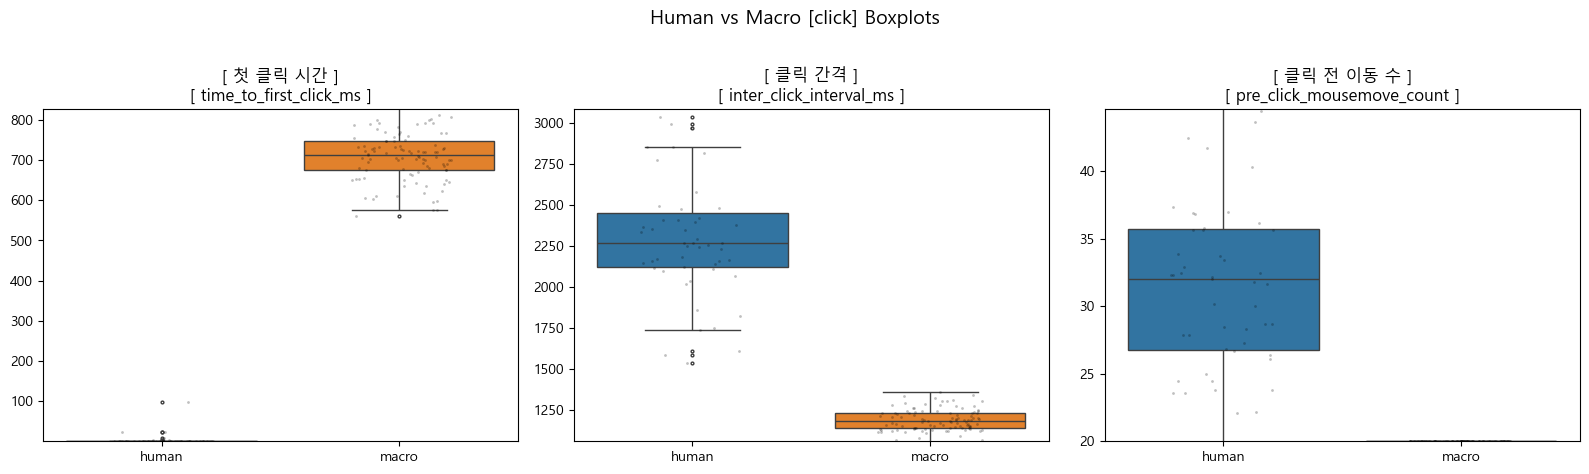

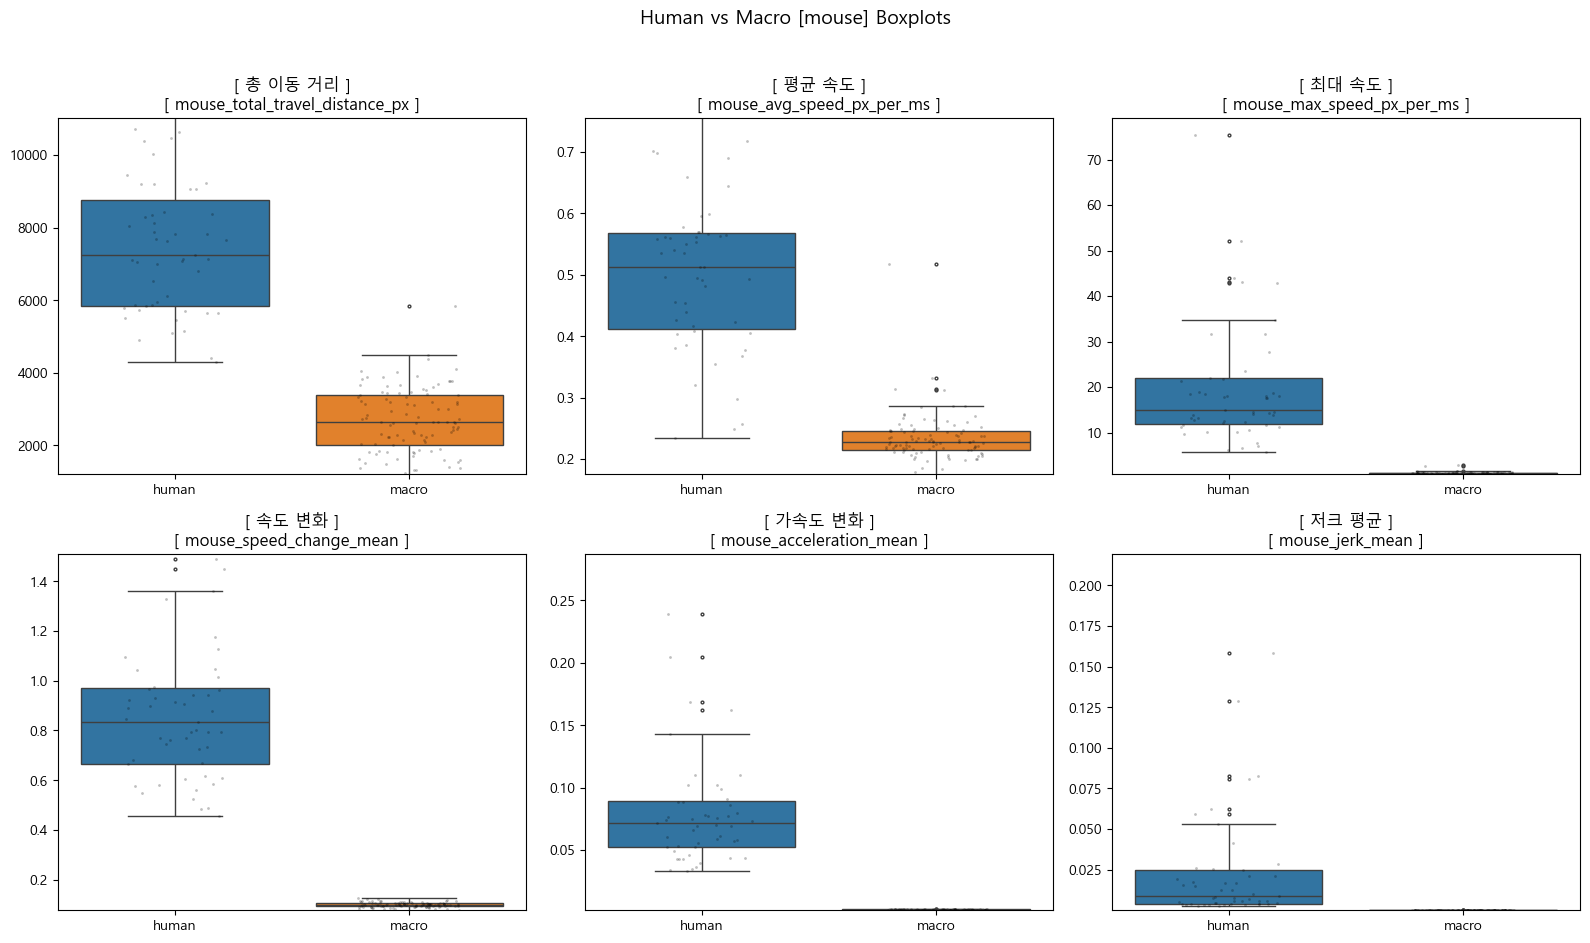

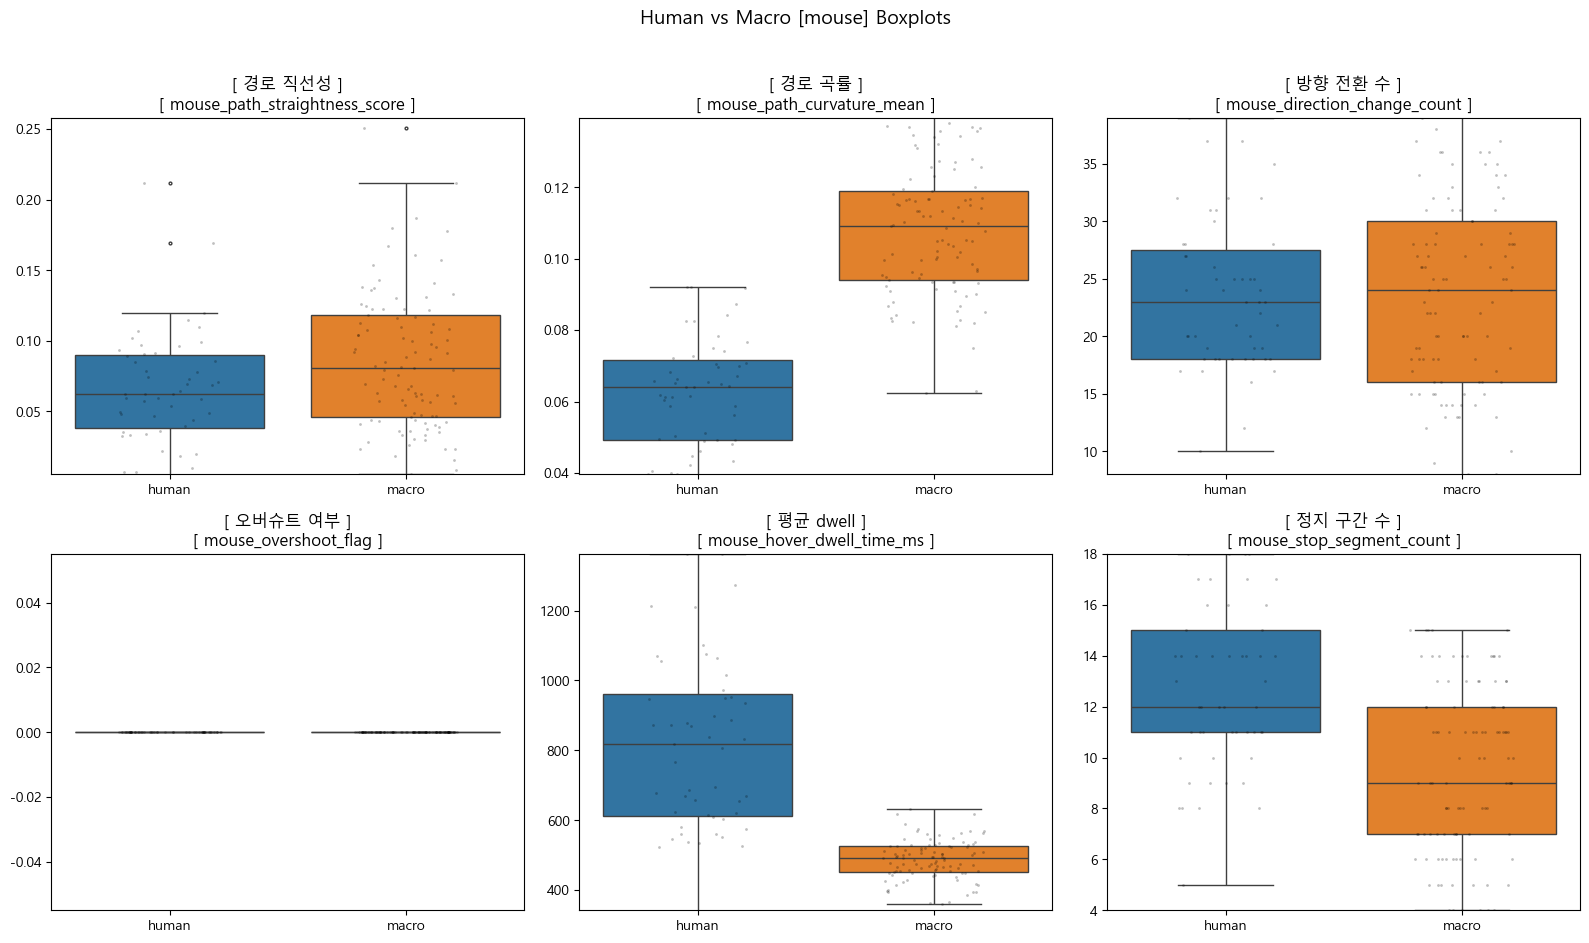

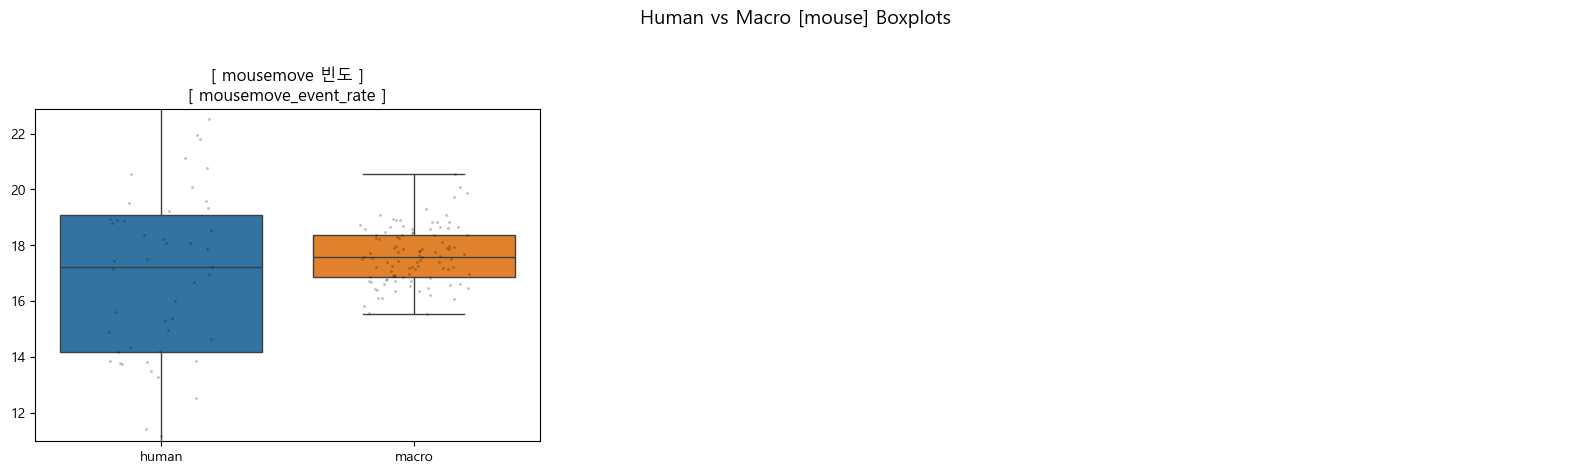

skip: keyboard


In [56]:
# 박스 플롯 — 그룹별, p1~p99 클리핑 + strip plot 으로 샘플 분포 표시

N_COLS = 3
N_FEATURES = 6
MAX_STRIP_PER_LABEL = 300

def draw_boxplot(group: str, features: list[str]) -> None:
    """행동 feature 그룹별 boxplot 그리기
    
    Args:
        group (str): feature 그룹명
        features (list[str]): feature 이름 리스트
    """

    features = [feature for feature in features if feature not in EXCLUDE_COL and feature in USABLE_FEATURES]

    if not features:
        print("skip:", group)
        return
    
    for start in range(0, len(features), N_FEATURES):
        subset = features[start: start + N_FEATURES]

        rows = int(np.ceil(len(subset) / N_COLS))

        fig, axes = plt.subplots(rows, N_COLS, figsize=(16, 4.6 * rows))

        axes = np.array(axes).reshape(rows, N_COLS)

        for i, feature in enumerate(subset):
            r = i // N_COLS
            c = i % N_COLS
            ax = axes[r, c]

            s = pd.to_numeric(df[feature], errors="coerce")

            plot_df = pd.DataFrame(
                {
                    "label": df["label"],
                    "value": s,
                }
            ).dropna()

            feature_ko = FEATURE_NAME_KR.get(feature, feature)

            if plot_df.empty:
                ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
                ax.axis("off")
                continue

            sns.boxplot(
                data=plot_df,
                x="label",
                y="value",
                hue="label",
                order=["human", "macro"],
                hue_order=["human", "macro"],
                legend=False,
                dodge=False,
                ax=ax,
                fliersize=2,
            )

            strip_parts = []

            for label in ["human", "macro"]:
                part = plot_df[plot_df["label"] == label]

                if part.empty:
                    continue

                strip_parts.append(
                    part.sample(
                        min(len(part), MAX_STRIP_PER_LABEL),
                        random_state=42,
                    )
                )

            if strip_parts:
                strip_df = pd.concat(strip_parts, ignore_index=True)

                sns.stripplot(
                    data=strip_df,
                    x="label",
                    y="value",
                    ax=ax,
                    color="black",
                    alpha=0.25,
                    size=2,
                    jitter=0.22,
                )

            q_low = plot_df["value"].quantile(0.01)
            q_high = plot_df["value"].quantile(0.99)
            if q_high > q_low:
                ax.set_ylim(q_low, q_high)

            ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
            ax.set_xlabel("")
            ax.set_ylabel("")

        total_axes = rows * N_COLS

        for j in range(len(subset), total_axes):
            r = j // N_COLS
            c = j % N_COLS
            axes[r, c].axis("off")

        fig.suptitle(
            f"Human vs Macro [{group}] Boxplots",
            y=1.02,
            fontsize=14,
        )

        plt.tight_layout()
        plt.show()


for group, features in FEATURE_GROUPS.items():
    draw_boxplot(group, features)

### 3-2 상관관계 분석

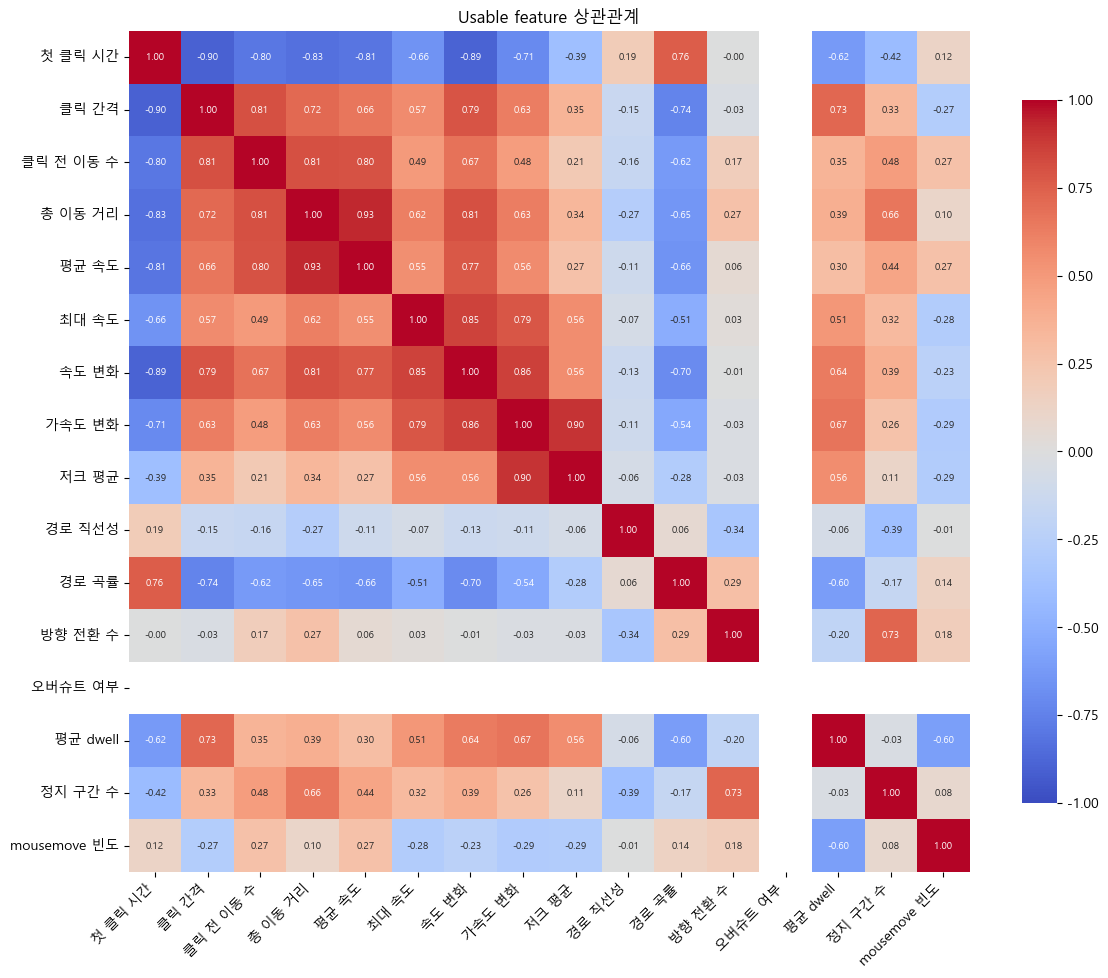

In [57]:
# usable feature 간 상관관계 (NaN 제외)

X_corr = df[USABLE_FEATURES].apply(pd.to_numeric, errors="coerce")
corr = X_corr.corr()

# 한글 라벨
label_map = {f: FEATURE_NAME_KR.get(f, f) for f in corr.columns}
corr_ko = corr.rename(columns=label_map, index=label_map)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_ko,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 7},
)
plt.title("Usable feature 상관관계")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
# |corr| > 0.8 인 feature 쌍 (다중공선성 후보 — 학습 시 한쪽 제거 검토)

high_corr_pairs: list[dict] = []
for i, f1 in enumerate(corr.columns):
    for f2 in corr.columns[i + 1:]:
        c = corr.loc[f1, f2]
        if pd.notna(c) and abs(c) > 0.8:
            high_corr_pairs.append({
                "feature_1": FEATURE_NAME_KR.get(f1, f1),
                "feature_2": FEATURE_NAME_KR.get(f2, f2),
                "corr": round(c, 3),
            })

high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("corr", key=abs, ascending=False)
    .reset_index(drop=True)
)
print(f"|corr| > 0.8 쌍: {len(high_corr_df)}개")
display(high_corr_df)

|corr| > 0.8 쌍: 13개


,feature_1,feature_2,corr
0,총 이동 거리,평균 속도,0.932
1,첫 클릭 시간,클릭 간격,-0.903
2,가속도 변화,저크 평균,0.899
3,첫 클릭 시간,속도 변화,-0.895
4,속도 변화,가속도 변화,0.862
5,최대 속도,속도 변화,0.855
6,첫 클릭 시간,총 이동 거리,-0.831
7,클릭 전 이동 수,총 이동 거리,0.810
8,클릭 간격,클릭 전 이동 수,0.809
9,총 이동 거리,속도 변화,0.809


### 3-3 PCA

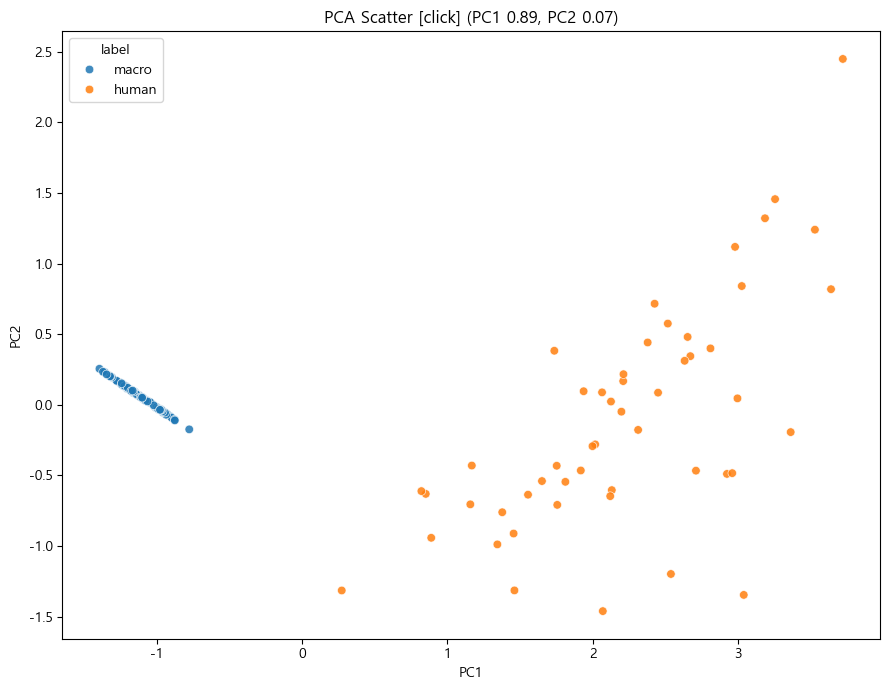

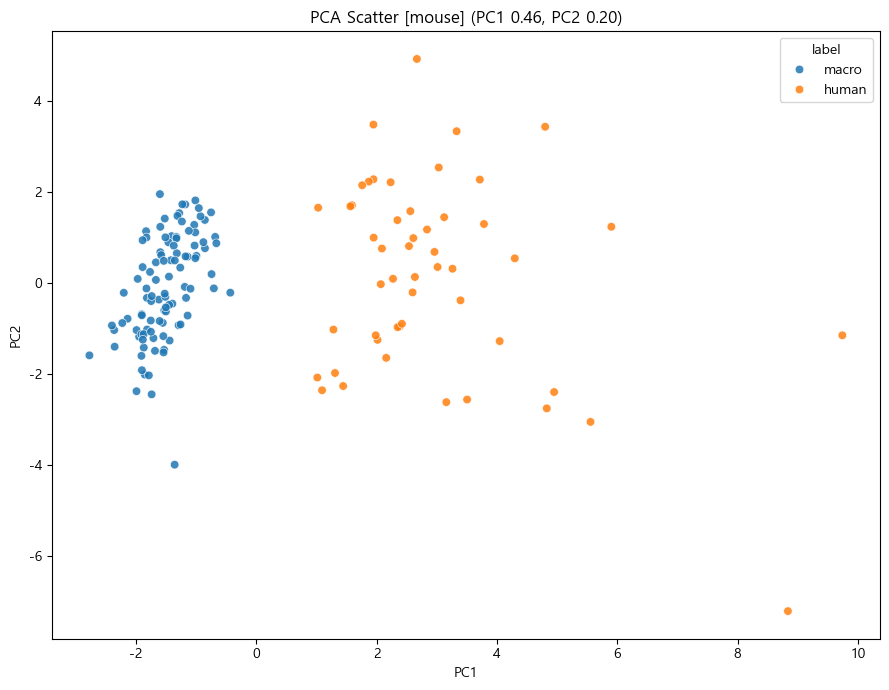

skip PCA: keyboard


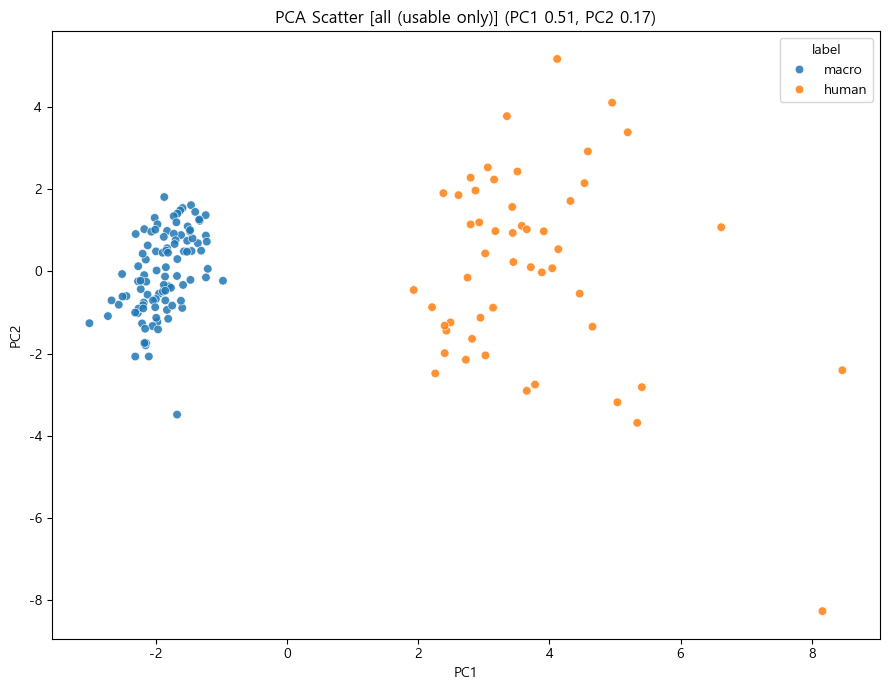

In [59]:
def draw_pca_scatter(title: str, features: list[str]) -> None:
    """PCA scatter plot 그리기
    
    Args:
        title (str): plot 제목
        features (list[str]): PCA에 사용할 feature 이름 리스트
    """

    features = [feature for feature in features if feature not in EXCLUDE_COL and feature in USABLE_FEATURES]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = df[features].apply(pd.to_numeric, errors="coerce")

    features = [feature for feature in features if X[feature].notna().sum() > 0]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = X[features]

    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=2, random_state=42)),
        ]
    )

    xy = pipe.fit_transform(X)
    pca = pipe.named_steps["pca"]
    explained = pca.explained_variance_ratio_

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        x=xy[:, 0],
        y=xy[:, 1],
        hue=df["label"],
        s=38,
        alpha=0.85,
    )

    plt.title(
        f"PCA Scatter [{title}] "
        f"(PC1 {explained[0]:.2f}, PC2 {explained[1]:.2f})"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

for group, features in FEATURE_GROUPS.items():
    draw_pca_scatter(group, features)

draw_pca_scatter("all (usable only)", USABLE_FEATURES)

## 4. Personal EDA

트리비얼 위험 feature 단독 분리도 검증 (본인 작업 영역).

검증 후보 (변환 코드 jsonl_to_trial.py 주석에 표시된 위험):
- `time_to_first_click_ms` — 사람 ≈ 0 (트리거 클릭), 매크로 양수
- `pre_click_mousemove_count` — 매크로 정확히 20 (BEZIER_POINTS 노출)
- `mouse_hover_dwell_time_ms` — stop 임계 영향, 사람 풍부 / 매크로 빈약
- `mouse_overshoot_flag` — DOM 부재로 minDist ≈ 0, 사실상 "직전 500ms 24px+ 움직임" 검출

## 5. 분석 리포트

(본인 작업)